In [1]:
from chronos import ChronosPipeline

/opt/anaconda3/envs/ml_chronos/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_47822/3697765711.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_47822/3697765711.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M")["y"].sum().reset_index()


Monthly splits: 84 train / 12 test

=== Chronos Monthly Test Metrics Summary Table ===
  Frequency            RMSE                         MSE             MAE  \
0   Monthly  501,059,901.20  251,061,024,592,126,880.00  398,566,747.08   

       R^2    MAPE  
0  -1.4867  27.15%  

=== 6-ROW Table (Monthly RMSE & RMSE/mean) ===
  Time period    Results         Prophet
0     Monthly       RMSE  501,059,901.20
1     Monthly  RMSE/mean          39.55%


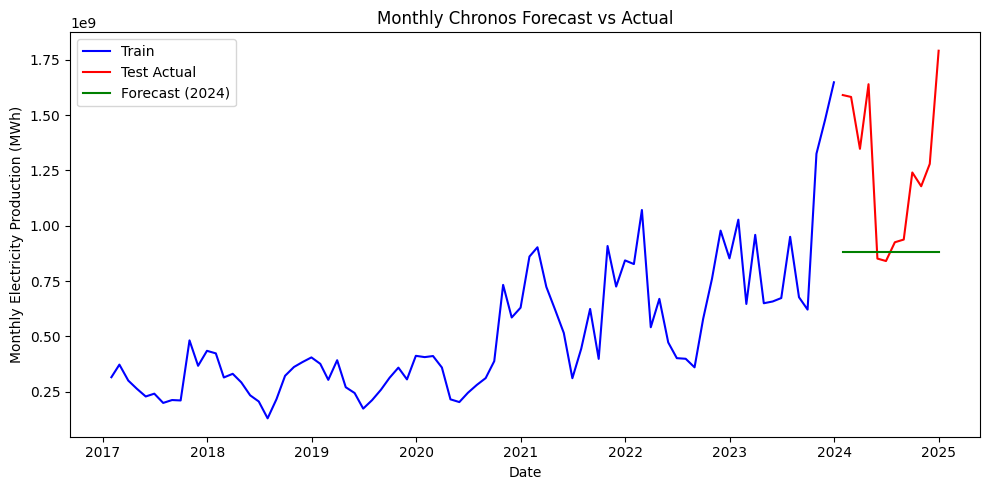

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 1) LOAD & PREPROCESS HOURLY DATA
# -----------------------------
df = pd.read_csv("final_offshore_data_2017_2025.csv")

# Fix hour = 24 issue (convert to 0)
df[["date", "hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1
df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")

# Define target variable: y = volume
df["y"] = df["volume"]

# Sort data by datetime and set 'ds' as datetime index (required for resampling)
df.sort_values("ds", inplace=True)
df.set_index("ds", inplace=True)

# -----------------------------
# 2) AGGREGATE TO MONTHLY DATA
# -----------------------------
# Sum hourly data for each month
df_monthly = df.resample("M")["y"].sum().reset_index()

# -----------------------------
# 3) TRAIN/TEST SPLIT (Monthly)
# -----------------------------
# Define training data: all observations before 2024-01-01
# Define testing data: observations from 2024-01-01 to 2025-01-01
train_month = df_monthly[df_monthly["ds"] < "2024-01-01"].copy()
test_month  = df_monthly[(df_monthly["ds"] >= "2024-01-01") & (df_monthly["ds"] < "2025-01-01")].copy()

print("Monthly splits:", len(train_month), "train /", len(test_month), "test")

# -----------------------------
# 4) Convert Train Data to 1D Tensor (Context for Chronos)
# -----------------------------
# Chronos expects a 1D tensor as historical context input
context_month = torch.tensor(train_month["y"].values, dtype=torch.float32)
pred_length_month = len(test_month)  # e.g., 12 months

# -----------------------------
# 5) LOAD THE PRETRAINED CHRONOS PIPELINE
# -----------------------------
# Ensure you use a supported Python version (e.g., 3.9 or 3.10)
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",         # switch to "cuda" if using GPU
    torch_dtype=torch.float32
)

# -----------------------------
# 6) Forecast with Chronos (Monthly)
# -----------------------------
def forecast_with_chronos(context, forecast_horizon):
    # Get quantile predictions; quantile_levels=[0.5] = median forecast
    quantiles, mean_preds = pipeline.predict_quantiles(
        context=context,
        prediction_length=forecast_horizon,
        quantile_levels=[0.5],
        limit_prediction_length=False  # allow full forecast horizon
    )
    # Output is (batch_size, num_samples, forecast_horizon)
    forecast_avg = mean_preds[0].mean(dim=0).detach().cpu().numpy()
    forecast_avg = np.atleast_1d(forecast_avg)
    if forecast_avg.size == 1 and forecast_horizon > 1:
        forecast_avg = np.full((forecast_horizon,), forecast_avg.item())
    return forecast_avg

forecast_month = forecast_with_chronos(context_month, pred_length_month)

# -----------------------------
# 7) Compute Evaluation Metrics for Monthly Forecasts
# -----------------------------
def compute_metrics(y_true, y_pred):
    mse_val = mean_squared_error(y_true, y_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)
    mape_val = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return mse_val, rmse_val, mae_val, r2_val, mape_val

y_true_month = test_month["y"].values
mse_m, rmse_m, mae_m, r2_m, mape_m = compute_metrics(y_true_month, forecast_month)

# -----------------------------
# 8) Assemble a Summary Table of Metrics (Monthly)
# -----------------------------
summary_data = {
    "Frequency": ["Monthly"],
    "RMSE":  [f"{rmse_m:,.2f}"],
    "MSE":   [f"{mse_m:,.2f}"],
    "MAE":   [f"{mae_m:,.2f}"],
    "R^2":   [f"{r2_m:.4f}"],
    "MAPE":  [f"{mape_m:,.2f}%"],
}
df_summary = pd.DataFrame(summary_data)
print("\n=== Chronos Monthly Test Metrics Summary Table ===")
print(df_summary)

# -----------------------------
# 9) Build the 6-Row Table: RMSE & RMSE/mean for Monthly
# -----------------------------
mean_mo = test_month["y"].mean()
rmse_over_mean_mo = (rmse_m / mean_mo) * 100

table_data_rmse = {
    "Time period": ["Monthly", "Monthly"],
    "Results": ["RMSE", "RMSE/mean"],
    "Prophet": [f"{rmse_m:,.2f}", f"{rmse_over_mean_mo:,.2f}%"]
}
df_results_rmse = pd.DataFrame(table_data_rmse)
print("\n=== 6-ROW Table (Monthly RMSE & RMSE/mean) ===")
print(df_results_rmse)

# -----------------------------
# 10) Plot Monthly Forecast vs Actual
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_month["ds"], train_month["y"], color="blue", label="Train")
plt.plot(test_month["ds"], test_month["y"], color="red", label="Test Actual")
plt.plot(test_month["ds"], forecast_month, color="green", label="Forecast (2024)")
plt.title("Monthly Chronos Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Electricity Production (MWh)")
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_47822/2305437816.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")


Weekly splits: 366 train / 52 test

Weekly Forecast Metrics:
RMSE: 122,354,549.94
MAE: 106,641,553.48
MSE: 14,970,635,890,541,822.00
R²: -0.0560
MAPE: 47.68%


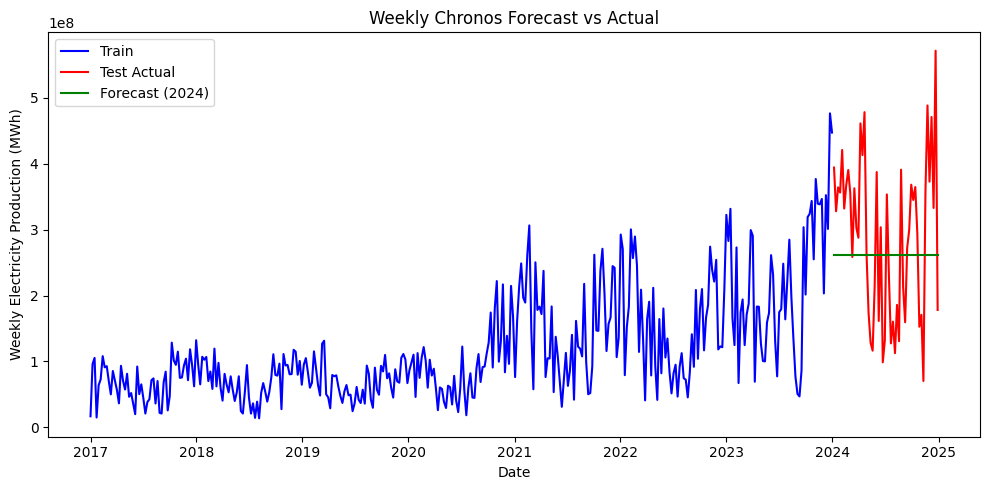

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------
# 1) Load & Preprocess Hourly Data
# -------------------------------
df = pd.read_csv("final_offshore_data_2017_2025.csv")

# Fix the issue where hour = 24 by converting it to 0
df[["date", "hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1

# Create the datetime column 'ds' from date and hour
df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")

# Define the target variable y = volume
df["y"] = df["volume"]

# Sort by datetime and set "ds" as the index (needed for resampling)
df.sort_values("ds", inplace=True)
df.set_index("ds", inplace=True)

# -------------------------------
# 2) Aggregate to Weekly Data
# -------------------------------
# Resample hourly data to weekly sums (MWh production per week)
df_weekly = df.resample("W")["y"].sum().reset_index()

# -------------------------------
# 3) Split Weekly Data into Train and Test
# -------------------------------
# Define:
# - TRAIN: all weeks where ds < "2024-01-01"
# - TEST: weeks where 2024-01-01 ≤ ds < "2025-01-01"
train_week = df_weekly[df_weekly["ds"] < "2024-01-01"].copy()
test_week  = df_weekly[(df_weekly["ds"] >= "2024-01-01") & (df_weekly["ds"] < "2025-01-01")].copy()

print("Weekly splits:", len(train_week), "train /", len(test_week), "test")

# -------------------------------
# 4) Convert Training Data to 1D Tensor (Context for Chronos)
# -------------------------------
context_week = torch.tensor(train_week["y"].values, dtype=torch.float32)
pred_length_week = len(test_week)  # Forecast horizon (e.g., number of weeks in 2024)

# -------------------------------
# 5) Load the Pretrained Chronos Pipeline
# -------------------------------
# Make sure you're running in a supported environment (Python 3.9/3.10)
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",         # Use "cuda" if you have a GPU
    torch_dtype=torch.float32  # Or torch.bfloat16 if needed
)

# -------------------------------
# 6) Forecasting Function with Chronos
# -------------------------------
def forecast_with_chronos(context, forecast_horizon):
    # Request quantile forecast using quantile_levels=[0.5] for the median
    quantiles, mean_preds = pipeline.predict_quantiles(
        context=context,
        prediction_length=forecast_horizon,
        quantile_levels=[0.5],
        limit_prediction_length=False  # Allows full-length forecasting
    )
    # Expected shape of mean_preds: (batch_size, num_samples, forecast_horizon)
    # Take the mean across samples (axis=1); assume batch_size == 1
    forecast_avg = mean_preds[0].mean(dim=0).detach().cpu().numpy()
    # Ensure forecast_avg is at least 1D
    forecast_avg = np.atleast_1d(forecast_avg)
    # If result is a single value but horizon > 1, repeat it
    if forecast_avg.size == 1 and forecast_horizon > 1:
        forecast_avg = np.full((forecast_horizon,), forecast_avg.item())
    return forecast_avg

# Generate forecast for the test set
forecast_week = forecast_with_chronos(context_week, pred_length_week)

# -------------------------------
# 7) (Optional) Compute Metrics for Weekly Forecast
# -------------------------------
def compute_metrics(y_true, y_pred):
    mse_val = mean_squared_error(y_true, y_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)
    mape_val = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return mse_val, rmse_val, mae_val, r2_val, mape_val

y_true_week = test_week["y"].values
mse_w, rmse_w, mae_w, r2_w, mape_w = compute_metrics(y_true_week, forecast_week)

print("\nWeekly Forecast Metrics:")
print(f"RMSE: {rmse_w:,.2f}")
print(f"MAE: {mae_w:,.2f}")
print(f"MSE: {mse_w:,.2f}")
print(f"R²: {r2_w:.4f}")
print(f"MAPE: {mape_w:,.2f}%")

# -------------------------------
# 8) Plot Weekly Forecast vs Actual
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_week["ds"], train_week["y"], color="blue", label="Train")
plt.plot(test_week["ds"], test_week["y"], color="red", label="Test Actual")
plt.plot(test_week["ds"], forecast_week, color="green", label="Forecast (2024)")
plt.title("Weekly Chronos Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Production (MWh)")
plt.legend()
plt.tight_layout()
plt.show()
